In [1]:
import logging
import sys
import os
from os.path import join
from copy import deepcopy

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from IPython.display import display, clear_output
from tqdm import tqdm

sys.path.insert(0, "../../ABC-SN/code")
import abcsn_config
import abcsn_training
import data_degrading as dg
import data_plotting as dplt
import data_preparation as dp
import preprocessing

sys.path.insert(0, "../code")
import review_spectrum as rs
import spectral_features as sf
import measure_signal as ms

from importlib import reload

2026-03-12 15:56:18.448071: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
df_data, df_metadata, wvl = rs.load_sn_data()
FFTd_S_data, FFTd_S_metadata, FFTd_N_data, FFTd_N_metadata = rs.load_FFTdenoised_data()
df_SNRmetadata = rs.load_SNRmetadata()

In [3]:
sn_name = "sn1995bd"
sn_phase = -7.1
sn_subtype = "Ia-91T"
mask = df_SNRmetadata["SN Name"] == sn_name
mask &= df_SNRmetadata["Spectral Phase"] == sn_phase

spectrum = df_data[mask].to_numpy()[0]

df_SNRmetadata[mask]

,SN Name,SN Subtype,SN Subtype ID,SN Maintype,SN Maintype ID,Spectral Phase,Denoising Parameter,minima_i,searchBlu,searchRed,useBlu,useRed,maxBlu,maxRed,noiseWindowBlu,noiseWindowRed
2041,sn1995bd,Ia-91T,1,Ia,0,-7.1,20.0,NaN,500.0,0.0,False,True,0.0,0.0,100.0,100.0


/Users/admin/Code/spec_res/nb/../code/measure_signal.py:306: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


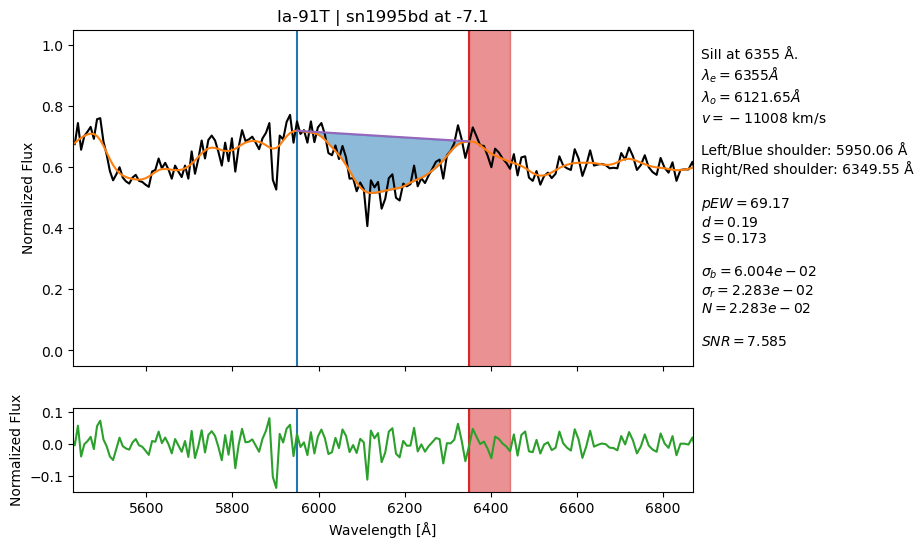

In [4]:
specsnr = ms.SpectrumSNR(
    sn_name,
    sn_subtype,
    sn_phase,
    wvl,
    spectrum)
specsnr.summarize()
specsnr.minmax_normalize()
specsnr.set_spectral_feature()
specsnr.denoise_gaussian(20)
specsnr.find_spectral_line(
    feature_search_bounds=(500, 0),
    minima_i=None,
    plot=False)
specsnr.find_spectral_shoulders(
    blu_shoulder_nudge=0,
    red_shoulder_nudge=0,
)
specsnr.calc_pEW()
specsnr.measure_feature_noise(
    noise_window_blu=100,
    noise_window_red=100,
    useBlu=False,
    useRed=True,
)
specsnr.measure_SNR(plot=True)

In [5]:
reload(ms)
logging.getLogger().setLevel(logging.WARNING)

selected_subtype = "Ic-norm"
specsnr_objs = []
for i in tqdm(range(df_data.shape[0])):
    options = {}
    sn_name = df_metadata["SN Name"][i]
    sn_subtype = df_metadata["SN Subtype"][i]
    sn_phase = df_metadata["Spectral Phase"][i]

    if sn_subtype != selected_subtype:
        continue
    
    SNRmetadata_mask = df_SNRmetadata["SN Name"] == sn_name
    SNRmetadata_mask &= df_SNRmetadata["Spectral Phase"] == sn_phase
    

    if np.isnan(df_SNRmetadata.loc[SNRmetadata_mask, "minima_i"].values[0]):
        options["minima_i"] = None
    else:
        options["minima_i"] = df_SNRmetadata.loc[SNRmetadata_mask, "minima_i"].values[0]

    options["sd"] = df_SNRmetadata.loc[SNRmetadata_mask, "Denoising Parameter"].values[0]
    if (options["sd"] == -999) or (np.isnan(options["sd"])):
        continue
    options["searchBlu"] = df_SNRmetadata.loc[SNRmetadata_mask, "searchBlu"].values[0]
    options["searchRed"] = df_SNRmetadata.loc[SNRmetadata_mask, "searchRed"].values[0]
    options["useBlu"] = df_SNRmetadata.loc[SNRmetadata_mask, "useBlu"].values[0]
    options["useRed"] = df_SNRmetadata.loc[SNRmetadata_mask, "useRed"].values[0]
    options["maxBlu"] = int(df_SNRmetadata.loc[SNRmetadata_mask, "maxBlu"].values[0])
    options["maxRed"] = int(df_SNRmetadata.loc[SNRmetadata_mask, "maxRed"].values[0])
    options["noiseWindowBlu"] = df_SNRmetadata.loc[SNRmetadata_mask, "noiseWindowBlu"].values[0]
    options["noiseWindowRed"] = df_SNRmetadata.loc[SNRmetadata_mask, "noiseWindowRed"].values[0]

    specsnr = ms.SpectrumSNR(
        sn_name,
        sn_subtype,
        sn_phase,
        wvl,
        deepcopy(df_data.loc[i].values)
    )
    specsnr.summarize()
    specsnr.minmax_normalize()
    specsnr.set_spectral_feature()
    specsnr.denoise_gaussian(options["sd"])
    specsnr.find_spectral_line(
        feature_search_bounds=(options["searchBlu"], options["searchRed"]),
        minima_i=options["minima_i"],
        plot=False)
    specsnr.find_spectral_shoulders(
        blu_shoulder_nudge=options["maxBlu"],
        red_shoulder_nudge=options["maxRed"],
    )
    specsnr.calc_pEW()
    specsnr.measure_feature_noise(
        noise_window_blu=options["noiseWindowBlu"],
        noise_window_red=options["noiseWindowRed"],
        useBlu=options["useBlu"],
        useRed=options["useRed"],
    )
    specsnr.measure_SNR(plot=False)
    specsnr_objs.append(specsnr)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3635/3635 [00:12<00:00, 279.65it/s]


In [6]:
# sort_by_SNR = np.argsort([specsnr.SNR for specsnr in specsnr_objs])
# sorted_specsnr_objs = np.array(specsnr_objs)[sort_by_SNR][::-1]
# sorted_specsnr_objs = np.array(specsnr_objs)

In [7]:
# for i in range(num_sn_subtype):
#     SN_i = df_meta_subtype["SN Name"].unique().to_numpy()[i]
#     SN_i_mask = df_meta_subtype["SN Name"] == SN_i
    
#     df_data_SN_i = df_data_subtype.loc[SN_i_mask]
#     df_meta_SN_i = df_meta_subtype.loc[SN_i_mask]
    
#     phases_SN_i = df_meta_SN_i["Spectral Phase"].to_numpy()
#     spec_SN_i = df_data_SN_i.to_numpy()
    
#     num_spec = spec_SN_i.shape[0]
#     fig, axes = plt.subplots(ncols=1, nrows=num_spec, figsize=(6, num_spec))
#     for j in range(num_spec):
#         if num_spec == 1:
#             ax = axes
#         else:
#             ax = axes[j]
#         ax.axis("off")
#         ax.set_xlim((4500, 7000))
#         ax.plot(wvl, spec_SN_i[j])
        
#         vertical_midpoint = np.mean(ax.get_ylim())
#         horizontal_text_location = ax.get_xlim()[1]
#         ax.text(
#             horizontal_text_location, vertical_midpoint,
#             f"{SN_i}\n{phases_SN_i[j]} days",
#             ha="left", va="center"
#         )
#     fig.show()

In [1]:
sort_by_SNR = np.argsort([specsnr.SNR for specsnr in specsnr_objs])
# sort_by_SNR = np.argsort([specsnr.S for specsnr in specsnr_objs])
sorted_specsnr_objs = np.array(specsnr_objs)[sort_by_SNR][::-1]
# sorted_specsnr_objs = np.array(specsnr_objs)

num_rows = 10
i = 0
while True:
    fig, axes = plt.subplots(ncols=1, nrows=num_rows, sharex=True, figsize=(6, num_rows))
    # fig.subplots_adjust(wspace=.5)

    for j, ax in enumerate(axes.flatten()):
        specsnr_j = sorted_specsnr_objs[i+j]
        
        ax.set_xlim((4500, 7000))
        # ax.axis("off")
        ax.plot(wvl, specsnr_j.spectrum)
        vertical_midpoint = np.sum(ax.get_ylim()) / 2
        horizontal_text_location = ax.get_xlim()[1]
        ax.text(
            horizontal_text_location, vertical_midpoint,
            f"{specsnr_j.name}\n{specsnr_j.phase} days\nSNR={specsnr_j.SNR:.4f}",
            # f"{specsnr_j.name}\n{specsnr_j.phase} days\nS={specsnr_j.S:.4f}",
            ha="left", va="center"
        )
        ax.plot(specsnr_j.pc_wvl, specsnr_j.pseudo_cont, c="tab:orange")
    i += num_rows
    
    fig.show()

NameError: name 'np' is not defined